[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rpasquini/econometrics-book-notebooks/blob/main/en/ch4_inferencia_causal/6_synthetic_control_notebook.ipynb)

# Code companion: The Synthetic Control Method

This notebook accompanies the section [The Synthetic Control Method](6_synthetic_control.md). That section's interactive dashboards let you *feel* how the weights are built and how permutation inference works by moving controls; this notebook shows how the same problem is solved in a **real analysis pipeline**, combining Dashboard 1's mechanics (weight construction) and Dashboard 3's (permutation inference) into one applied workflow over two datasets:

1. **The same Uber/Austin simulation** that generates Dashboard 1 — frozen with a fixed seed into a `.csv` so the analysis is reproducible.
2. **The classic case study**: California's Proposition 99 (Abadie, Diamond & Hainmueller, 2010) — the paper that introduced the synthetic control method.

For each dataset we first implement a **from-scratch** version (to see the exact mechanics behind the estimator) and then the same idea using `scpi_pkg`, a package specialized in synthetic control and its prediction intervals.

## Citations

- Abadie, A., Diamond, A., & Hainmueller, J. (2010). *Synthetic Control Methods for Comparative Case Studies: Estimating the Effect of California's Tobacco Control Program.* Journal of the American Statistical Association, 105(490), 493–505.
- The Proposition 99 data comes from the R package `synthdid` (Arkhangelsky, Athey, Hirshberg, Imbens & Wager), BSD-3-Clause licensed — permits redistribution and reuse with attribution. Repository: [synth-inference/synthdid](https://github.com/synth-inference/synthdid).
- Cattaneo, M. D., Feng, Y., Palomba, F., & Titiunik, R. (2025). *scpi: Uncertainty Quantification for Synthetic Control Estimators.* Journal of Statistical Software, 113(1), 1–38.
- Cattaneo, M. D., Feng, Y., & Titiunik, R. (2021). *Prediction Intervals for Synthetic Control Methods.* Journal of the American Statistical Association, 116(536), 1865–1880.
- (For future reference) Abadie, A., Diamond, A., & Hainmueller, J. (2015). *Comparative Politics and the Synthetic Control Method.* American Journal of Political Science, 59(2), 495–510 — the West Germany reunification study, whose data is already downloaded under `data/` but not yet used in this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# scpi_pkg is not preinstalled on Colab -- installs quickly, safe to skip if already present
try:
    import scpi_pkg  # noqa: F401
except ImportError:
    %pip install -q scpi_pkg

from scpi_pkg.scdata import scdata
from scpi_pkg.scest import scest
from scpi_pkg.scpi import scpi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 7.1 MB/s eta 0:00:00


## Part 1 — The Uber/Austin simulation

`rides_thousands` is weekly completed rides (thousands), in Austin and an 18-city donor pool. The first 20 weeks are pre-intervention; the driver-incentive program starts in week 21. This is the same data generated by Dashboard 1, frozen with the same random seed (`comparison_mode="optimized"`, `true_effect=10%`).

In [2]:
uber = pd.read_csv('https://raw.githubusercontent.com/rpasquini/econometrics-book-notebooks/main/en/ch4_inferencia_causal/data/synthetic_control_uber_austin.csv')
uber.head()

,city,week,rides_thousands,population_m,income_k,drivers_k,lyft_share_pct,is_treated_unit,post_period
0,Austin,1,97.105096,1.8,72.0,9.5,38.0,1,0
1,Austin,2,93.093623,1.8,72.0,9.5,38.0,1,0
2,Austin,3,95.906988,1.8,72.0,9.5,38.0,1,0
3,Austin,4,97.470197,1.8,72.0,9.5,38.0,1,0
4,Austin,5,97.897667,1.8,72.0,9.5,38.0,1,0


### Estimator 1a — Synthetic control weights, from scratch

We reproduce the Dashboard 1 mechanics exactly: 8 predictors per city (4 demographic variables + 4 lagged ride observations at weeks 5, 10, 15, and 20), and solve

$$\min_W (X_1 - X_0 W)'V(X_1-X_0W) \quad \text{s.t. } W\ge 0,\ \mathbf{1}'W=1$$

with $V$ the "simple selector" (inverse-variance weighting of each predictor).

In [3]:
T0 = 20
HISTORY_WEEKS = [5, 10, 15, 20]
DEMO_COLS = ["population_m", "income_k", "drivers_k", "lyft_share_pct"]

def build_predictor_matrix(df, cities):
    rows = []
    for city in cities:
        sub = df[df.city == city]
        demo = sub[DEMO_COLS].iloc[0].values
        hist = sub[sub.week.isin(HISTORY_WEEKS)].sort_values("week")["rides_thousands"].values
        rows.append(np.concatenate([demo, hist]))
    return np.array(rows).T  # (8, n_cities)

def solve_weights(x1, x0):
    """Constrained least squares: minimize ||x1 - x0 @ w||_V s.t. w >= 0, sum(w) = 1."""
    J = x0.shape[1]
    V = 1.0 / np.maximum(x0.var(axis=1), 1e-6)

    def loss(w):
        diff = x1 - x0 @ w
        return float(diff @ (V * diff))

    res = minimize(loss, x0=np.full(J, 1.0 / J), method="SLSQP",
                    bounds=[(0.0, 1.0)] * J,
                    constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0}],
                    options={"maxiter": 300, "ftol": 1e-10})
    w = np.clip(res.x, 0, None)
    total = w.sum()
    return w / total if total > 0 else np.full(J, 1.0 / J)

donor_cities = sorted(uber.loc[uber.is_treated_unit == 0, "city"].unique())
X = build_predictor_matrix(uber, ["Austin"] + donor_cities)
w_uber = solve_weights(X[:, 0], X[:, 1:])

weights_table = pd.Series(w_uber, index=donor_cities).sort_values(ascending=False)
weights_table[weights_table > 0.01]

,0
Kansas City,0.383260
Boise,0.293238
Columbus,0.137009
Charlotte,0.106271
Albuquerque,0.045103
Salt Lake City,0.035119


In [4]:
pivot_uber = uber.pivot(index="city", columns="week", values="rides_thousands")
y_austin = pivot_uber.loc["Austin"].sort_index().values
y_donors = pivot_uber.loc[donor_cities].sort_index(axis=1).values
synthetic_uber = y_donors.T @ w_uber
gap_uber = y_austin - synthetic_uber

rmspe_pre_uber = np.sqrt(np.mean(gap_uber[:T0] ** 2))
tau_hat_uber = gap_uber[T0:].mean()
print(f"Pre-treatment RMSPE: {rmspe_pre_uber:.2f}")
print(f"tau_hat (mean post-treatment gap): {tau_hat_uber:.2f}")

Pre-treatment RMSPE: 1.77
tau_hat (mean post-treatment gap): 9.80


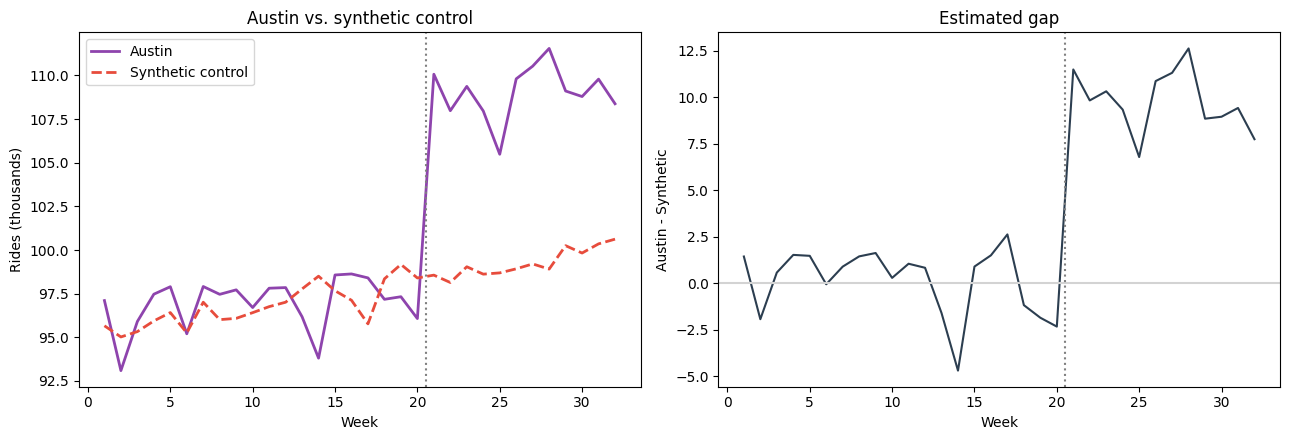

In [5]:
weeks = np.arange(1, len(y_austin) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(weeks, y_austin, label="Austin", color="#8e44ad", linewidth=2)
axes[0].plot(weeks, synthetic_uber, label="Synthetic control", color="#e74c3c", linestyle="--", linewidth=2)
axes[0].axvline(T0 + 0.5, color="gray", linestyle=":")
axes[0].set_xlabel("Week"); axes[0].set_ylabel("Rides (thousands)")
axes[0].set_title("Austin vs. synthetic control"); axes[0].legend()

axes[1].plot(weeks, gap_uber, color="#2c3e50")
axes[1].axhline(0, color="lightgray")
axes[1].axvline(T0 + 0.5, color="gray", linestyle=":")
axes[1].set_xlabel("Week"); axes[1].set_ylabel("Austin - Synthetic")
axes[1].set_title("Estimated gap")
plt.tight_layout(); plt.show()

**Interpretation.** The pre-treatment fit is nearly exact and the weights concentrate on a handful of cities (Kansas City, Boise, Columbus...) — the same sparsity seen in Dashboard 1 under `comparison_mode="optimized"`. $\hat\tau \approx 9.8$ is close to the true simulated effect (10%).

### Estimator 1b — The same problem with `scpi_pkg`

`scpi_pkg` is designed around outcome *features* and adjustment covariates (`cov_adj`), not a hand-built ADH-style predictor matrix. With its default configuration (no `features` specified), it uses **the entire pre-treatment outcome trajectory** as the predictor — here, all 20 weeks — rather than the specific set of 8 predictors (demographics + 4 lagged weeks) that Dashboard 1 builds.

**Important note:** because of this, don't expect `scpi_pkg`'s weight vector to exactly reproduce the one from the previous cell — they solve different specifications of the matching problem, even though both are reasonable ways to implement synthetic control. This is a good example of "the same idea, implemented with different tools" not always giving an identical answer. `scpi_pkg`'s default $V$ is also `'separate'` (a partitioned least-squares variant), different from the "simple selector" (inverse variance) Dashboard 1 uses.

In [6]:
period_pre_uber = np.arange(1, T0 + 1)
period_post_uber = np.arange(T0 + 1, uber.week.max() + 1)

data_uber = scdata(df=uber, id_var="city", time_var="week", outcome_var="rides_thousands",
                    period_pre=period_pre_uber, period_post=period_post_uber,
                    unit_tr="Austin", unit_co=donor_cities, constant=False, verbose=False)
est_uber = scest(data_uber, w_constr={"name": "simplex"})

w_scpi_uber = est_uber.w.iloc[:, 0].sort_values(ascending=False)
w_scpi_uber[w_scpi_uber > 0.01]

ID      donor         
Austin  Charlotte         0.487083
        Sacramento        0.285962
        Omaha             0.092707
        Boise             0.073174
        Salt Lake City    0.039090
        Fresno            0.021983
Name: 0, dtype: float64

## Part 2 — A classic case study: Proposition 99 in California

We now apply the same pipeline to the real data from Abadie, Diamond & Hainmueller (2010): annual cigarette consumption (`PacksPerCapita`, packs per capita) for California and 38 donor states, 1970–2000. California passed Proposition 99 (a large tobacco tax and control campaign) in 1988, effective from 1989.

In [7]:
prop99 = pd.read_csv('https://raw.githubusercontent.com/rpasquini/econometrics-book-notebooks/main/en/ch4_inferencia_causal/data/california_prop99.csv', sep=';')

In [8]:
PRE_YEARS = list(range(1970, 1989))
POST_YEARS = list(range(1989, 2001))
ALL_YEARS = PRE_YEARS + POST_YEARS
T0_PROP99 = len(PRE_YEARS)

pivot_prop99 = prop99.pivot(index="State", columns="Year", values="PacksPerCapita")
donor_states = [s for s in pivot_prop99.index if s != "California"]
prop99.head()

,State,Year,PacksPerCapita,treated
0,Alabama,1970,89.800003,0
1,Arkansas,1970,100.300003,0
2,Colorado,1970,124.800003,0
3,Connecticut,1970,120.000000,0
4,Delaware,1970,155.000000,0


### Estimator 1a (repeated) — From-scratch weights, on real data

Here the only predictor is the outcome itself (packs per capita) in each of the 19 pre-treatment years — the classic ADH approach when no additional covariates are used.

In [9]:
x1_prop99 = pivot_prop99.loc["California", PRE_YEARS].values
x0_prop99 = pivot_prop99.loc[donor_states, PRE_YEARS].values.T
w_prop99 = solve_weights(x1_prop99, x0_prop99)

weights_prop99 = pd.Series(w_prop99, index=donor_states).sort_values(ascending=False)
weights_prop99[weights_prop99 > 0.01]

,0
Utah,0.384979
Montana,0.271484
Nevada,0.185357
Connecticut,0.079059
New Hampshire,0.049002
Colorado,0.030119


In [10]:
synthetic_prop99 = pivot_prop99.loc[donor_states, ALL_YEARS].values.T @ w_prop99
actual_prop99 = pivot_prop99.loc["California", ALL_YEARS].values
gap_prop99 = actual_prop99 - synthetic_prop99

rmspe_pre_prop99 = np.sqrt(np.mean(gap_prop99[:T0_PROP99] ** 2))
print(f"Pre-treatment RMSPE: {rmspe_pre_prop99:.2f}")
print(f"Gap by 2000: {gap_prop99[-1]:.1f} packs per capita")

Pre-treatment RMSPE: 1.70
Gap by 2000: -26.9 packs per capita


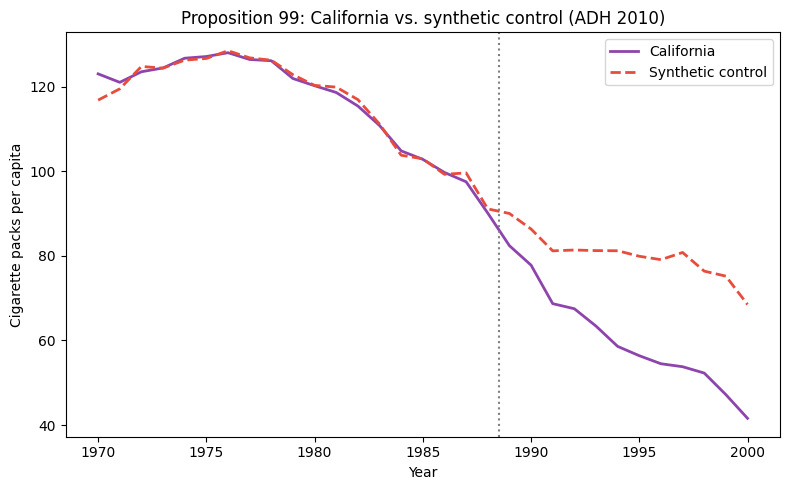

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ALL_YEARS, actual_prop99, label="California", color="#8e44ad", linewidth=2)
ax.plot(ALL_YEARS, synthetic_prop99, label="Synthetic control", color="#e74c3c", linestyle="--", linewidth=2)
ax.axvline(1988.5, color="gray", linestyle=":")
ax.set_xlabel("Year"); ax.set_ylabel("Cigarette packs per capita")
ax.set_title("Proposition 99: California vs. synthetic control (ADH 2010)")
ax.legend(); plt.tight_layout(); plt.show()

**Reproducing the classic result.** The weights concentrate on Utah, Montana, Nevada, Connecticut, and New Hampshire — the same donor set (with very similar weights) reported in Table 2 of ADH (2010). The gap by 2000 (~-27 packs per capita) also matches the published result: Proposition 99 substantially reduced cigarette consumption in California relative to its synthetic control.

### Estimator 1b (repeated) — `scpi_pkg` on Prop 99

With a single *feature* (the outcome) and no additional covariates, `scpi_pkg`'s default specification coincides with the classic ADH approach — so here we do expect weights very close to the previous cell's (unlike the Uber/Austin case, where demographics introduced a different specification).

In [12]:
period_pre_p99 = np.arange(1970, 1989)
period_post_p99 = np.arange(1989, 2001)

data_prop99 = scdata(df=prop99, id_var="State", time_var="Year", outcome_var="PacksPerCapita",
                      period_pre=period_pre_p99, period_post=period_post_p99,
                      unit_tr="California", unit_co=donor_states, constant=False, verbose=False)
est_prop99 = scest(data_prop99, w_constr={"name": "simplex"})

w_scpi_prop99 = est_prop99.w.iloc[:, 0].sort_values(ascending=False)
w_scpi_prop99[w_scpi_prop99 > 0.01]

ID          donor        
California  Utah             0.393905
            Montana          0.231842
            Nevada           0.204923
            Connecticut      0.109091
            New Hampshire    0.045428
            Colorado         0.014810
Name: 0, dtype: float64

## Estimator 2 — Permutation inference

We reproduce Dashboard 3's logic: reassign "treatment" to each donor unit in turn (using the rest as its own donor pool), compute $r_j = \text{RMSPE}_{post,j}/\text{RMSPE}_{pre,j}$ for each, and get a p-value based on Austin/California's rank within that distribution.

### On the Uber/Austin simulation

In [13]:
def leave_one_out_placebo(pivot, all_units, predictor_fn, T0):
    """Run the leave-one-out placebo procedure for every unit; return r_j and gaps."""
    gaps, rmspe_pre, rmspe_post = {}, {}, {}
    for unit in all_units:
        donors = [u for u in all_units if u != unit]
        x1, x0 = predictor_fn(unit, donors)
        w = solve_weights(x1, x0)
        synthetic = pivot.loc[donors].values.T @ w
        actual = pivot.loc[unit].values
        gap = actual - synthetic
        gaps[unit] = gap
        rmspe_pre[unit] = np.sqrt(np.mean(gap[:T0] ** 2))
        rmspe_post[unit] = np.sqrt(np.mean(gap[T0:] ** 2))
    r = {u: rmspe_post[u] / max(rmspe_pre[u], 1e-9) for u in all_units}
    return gaps, rmspe_pre, r

all_cities = ["Austin"] + donor_cities

def uber_predictors(unit, donors):
    X = build_predictor_matrix(uber, [unit] + donors)
    return X[:, 0], X[:, 1:]

gaps_uber, rmspe_pre_uber_all, r_uber = leave_one_out_placebo(
    pivot_uber, all_cities, uber_predictors, T0)

r_series_uber = pd.Series(r_uber).sort_values(ascending=False)
p_value_uber = float((r_series_uber >= r_uber["Austin"]).mean())
print(f"Austin's rank: {list(r_series_uber.index).index('Austin') + 1} of {len(r_series_uber)}")
print(f"p-value: {p_value_uber:.3f}")

Austin's rank: 1 of 19
p-value: 0.053


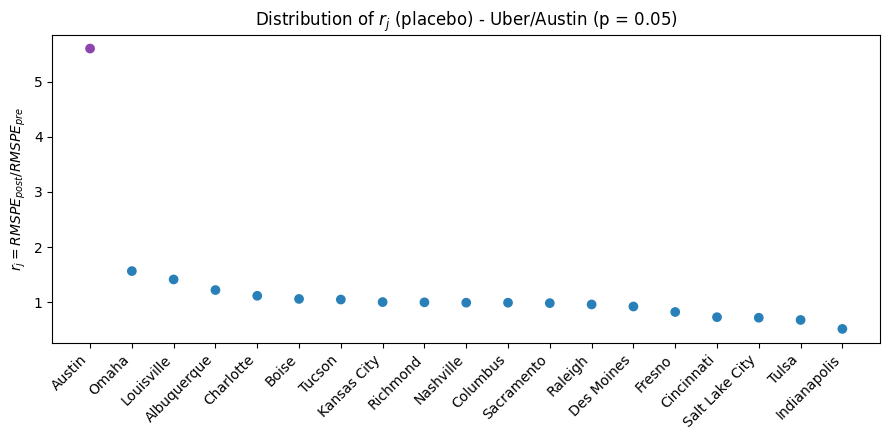

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#8e44ad" if u == "Austin" else "#2980b9" for u in r_series_uber.index]
ax.scatter(r_series_uber.index, r_series_uber.values, c=colors)
ax.set_xticks(range(len(r_series_uber)))
ax.set_xticklabels(r_series_uber.index, rotation=45, ha="right")
ax.set_ylabel(r"$r_j = RMSPE_{post}/RMSPE_{pre}$")
ax.set_title(f"Distribution of $r_j$ (placebo) - Uber/Austin (p = {p_value_uber:.2f})")
plt.tight_layout(); plt.show()

Austin lands near the upper tail of the placebo distribution — consistent with the simulated 10% effect and with what Dashboard 3 shows at `true_effect=10%` under a reasonable fit cutoff.

### On Proposition 99 — closing the loop with ADH's classic placebo distribution

In [15]:
def prop99_predictors(unit, donors):
    x1 = pivot_prop99.loc[unit, PRE_YEARS].values
    x0 = pivot_prop99.loc[donors, PRE_YEARS].values.T
    return x1, x0

all_states = ["California"] + donor_states
gaps_prop99, rmspe_pre_prop99_all, r_prop99 = leave_one_out_placebo(
    pivot_prop99[ALL_YEARS], all_states, prop99_predictors, T0_PROP99)

r_series_prop99 = pd.Series(r_prop99).sort_values(ascending=False)
p_value_prop99 = float((r_series_prop99 >= r_prop99["California"]).mean())
print(f"California's rank: {list(r_series_prop99.index).index('California') + 1} of {len(r_series_prop99)}")
print(f"p-value (all 39 states, no fit cutoff): {p_value_prop99:.3f}")

California's rank: 3 of 39
p-value (all 39 states, no fit cutoff): 0.077


We apply the same kind of fit cutoff Dashboard 3 uses (exclude donors whose pre-treatment RMSPE exceeds $k$ times California's own):

In [16]:
rmspe_pre_ca = rmspe_pre_prop99_all["California"]
for k in [2, 3, 5, float("inf")]:
    kept = [s for s in all_states if rmspe_pre_prop99_all[s] <= k * rmspe_pre_ca]
    r_kept = pd.Series({s: r_prop99[s] for s in kept}).sort_values(ascending=False)
    p = float((r_kept >= r_prop99["California"]).mean())
    label = "all" if k == float("inf") else f"{k}x"
    print(f"cutoff={label:>6}: donors kept={len(kept):>2}  p-value={p:.3f}")

cutoff=    2x: donors kept=30  p-value=0.100
cutoff=    3x: donors kept=33  p-value=0.091
cutoff=    5x: donors kept=35  p-value=0.086
cutoff=   all: donors kept=39  p-value=0.077


**Unlike Dashboard 3's clean simulation, the cutoff here doesn't necessarily sharpen the p-value.** Missouri and Virginia — the two states with a higher $r_j$ than California — actually fit *better* than California in the pre-treatment period (their pre-treatment RMSPE is 0.27x and 0.49x California's), so no "exclude poor fit" rule will remove them from the calculation, no matter how strict. They are states that fit well but had their own large, idiosyncratic move in the post-treatment period — a reminder that the RMSPE cutoff filters out placebos that never fit well to begin with, but doesn't guarantee excluding every large post-treatment gap if it comes from a well-fitting donor.

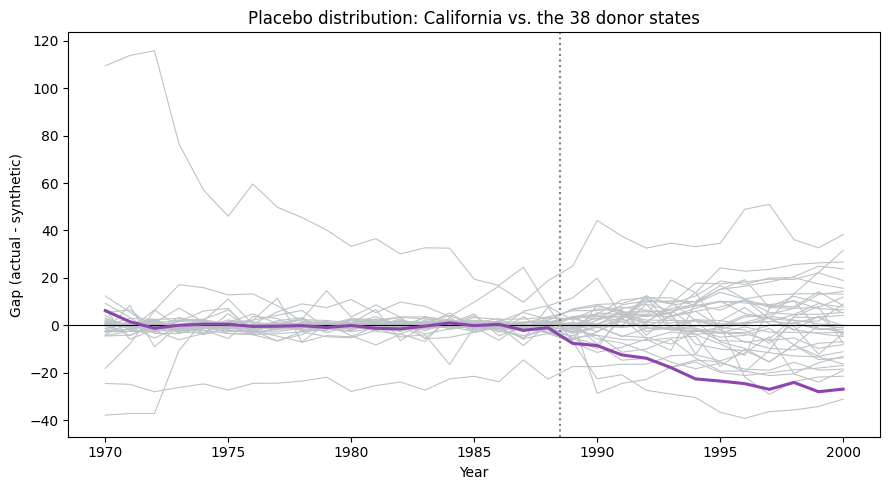

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
for state in all_states:
    color = "#8e44ad" if state == "California" else "#bdc3c7"
    lw = 2.2 if state == "California" else 0.8
    zorder = 5 if state == "California" else 1
    ax.plot(ALL_YEARS, gaps_prop99[state], color=color, linewidth=lw, zorder=zorder)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(1988.5, color="gray", linestyle=":")
ax.set_xlabel("Year"); ax.set_ylabel("Gap (actual - synthetic)")
ax.set_title("Placebo distribution: California vs. the 38 donor states")
plt.tight_layout(); plt.show()

This is, in essence, ADH (2010)'s Figure 4: California (thick line) departs much more sharply than most placebos toward the end of the post-treatment period.

### Contrast: `scpi_pkg`'s prediction intervals

`scpi_pkg` implements its own inference via `scpi()` — but this is a **materially different** approach, not a reproduction of the permutation p-value above. Instead of a placebo-based ranking, `scpi()` builds **prediction intervals** (Cattaneo, Feng & Titiunik, 2021) using a combination of simulation and bias/variance adjustment of $\hat Y_{1t}^N$. The two approaches answer related but non-interchangeable questions: one asks "how unusual is this gap compared to placebos?"; the other asks "what is the plausible range for the unobserved outcome, given estimation uncertainty?".

In [18]:
pi_prop99 = scpi(data_prop99, w_constr={"name": "simplex"}, sims=200, cores=1, verbose=False)
ci = pi_prop99.CI_all_gaussian
ci.head()

Lower       Upper     Length
ID         Time                                  
California 1989  80.154630  102.441269  22.286639
           1990  73.973009  101.269305  27.296296
           1991  64.942486   91.953631  27.011145
           1992  64.656960   91.933513  27.276553
           1993  62.677371   89.683166  27.005796

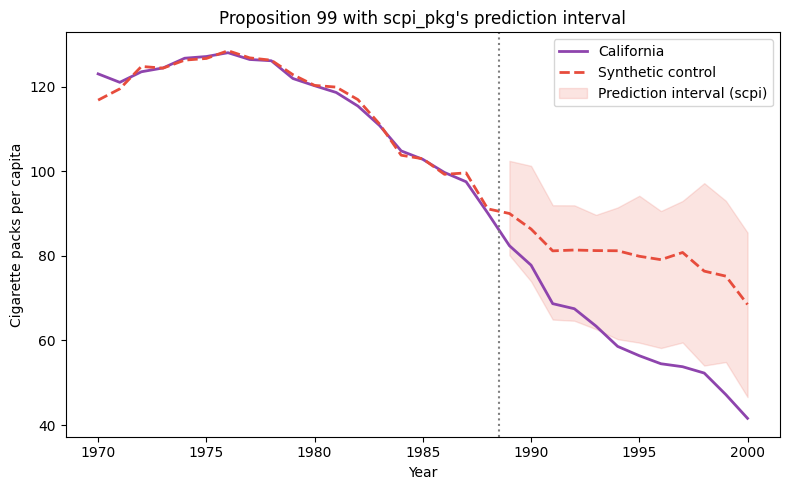

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ALL_YEARS, actual_prop99, label="California", color="#8e44ad", linewidth=2)
ax.plot(ALL_YEARS, synthetic_prop99, label="Synthetic control", color="#e74c3c", linestyle="--", linewidth=2)
ax.fill_between(POST_YEARS, ci["Lower"].values, ci["Upper"].values,
                 color="#e74c3c", alpha=0.15, label="Prediction interval (scpi)")
ax.axvline(1988.5, color="gray", linestyle=":")
ax.set_xlabel("Year"); ax.set_ylabel("Cigarette packs per capita")
ax.set_title("Proposition 99 with scpi_pkg's prediction interval")
ax.legend(); plt.tight_layout(); plt.show()

## For further exploration

- Change the fit cutoff (`k`) in Prop 99's permutation inference section and see how the p-value shifts as more poorly-fitting donors get excluded.
- Try restricting the from-scratch Uber/Austin pass to demographics only (dropping the 4 lagged weeks) and compare the resulting weights to Dashboard 1's under `predictor_set="demographics"`.
- Adjust `w_constr` in `scest`/`scpi` (e.g. `{"name": "lasso"}` instead of `"simplex"`) and see how the weights' sparsity changes.
- With the West Germany data already downloaded under `data/scpi_germany.csv` (Abadie, Diamond & Hainmueller, 2015), replicate the same pipeline as an extra exercise.